In [2]:
import inspect
import time

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

In [3]:
def wrangle(filepath, resample_rule="1H"):
    # Read Data into DataFrame
    df = pd.read_csv(filepath)

    # Select only the needed columns `date` and `pm2_5`
    df = df[["date", "pm2_5"]]

    # Change the name of the index
    df = df.rename(columns={"date": "timestamp"})

    # Change `date` string to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True)

    # Set `time` as the index
    df = df.set_index("timestamp")

    # Localize timezone and convert to Nairobi's timezone
    df.index = df.index.tz_localize("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["pm2_5"] < 50]

    # Resample to 1hr window. Remove `.to_frame()` to convert from dataframe to series
    y = df["pm2_5"].resample(resample_rule).mean().fillna(method="ffill")

    return y

In [4]:
filepath = r"C:\Users\Johnt\Downloads\Time Series Dar Es Salaam - Tanzania\air_quality_historical.csv"

In [5]:
df = wrangle(filepath, resample_rule="1H")
df.head()

C:\Users\Johnt\AppData\Local\Temp\ipykernel_18144\1561736669.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  y = df["pm2_5"].resample(resample_rule).mean().fillna(method="ffill")
C:\Users\Johnt\AppData\Local\Temp\ipykernel_18144\1561736669.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df["pm2_5"].resample(resample_rule).mean().fillna(method="ffill")


timestamp
2022-08-04 03:00:00+03:00    11.138095
2022-08-04 04:00:00+03:00    11.138095
2022-08-04 05:00:00+03:00    11.138095
2022-08-04 06:00:00+03:00    11.138095
2022-08-04 07:00:00+03:00    11.138095
Freq: h, Name: pm2_5, dtype: float64

EXPLORE

Plot a Time Series plot

<Axes: title={'center': 'Dar es Salaam PM2.5 Levels'}, xlabel='Date', ylabel='PM2.5 Level'>

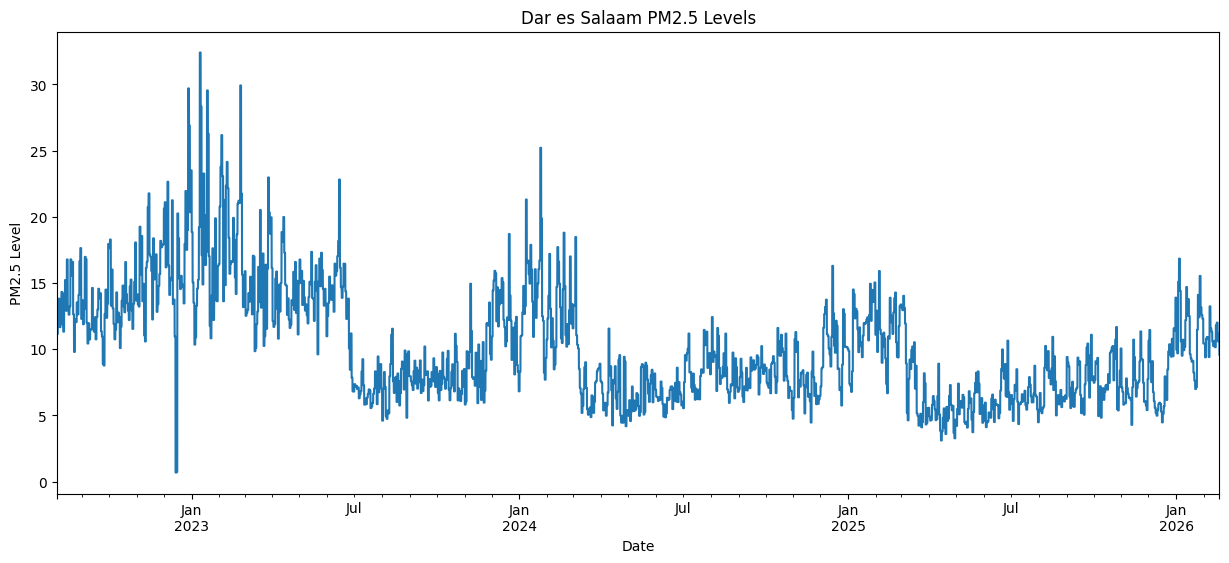

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))

# use ax=ax in your plot
df.plot(xlabel="Date", ylabel="PM2.5 Level", title="Dar es Salaam PM2.5 Levels", ax=ax)

Plot a Rolling Average

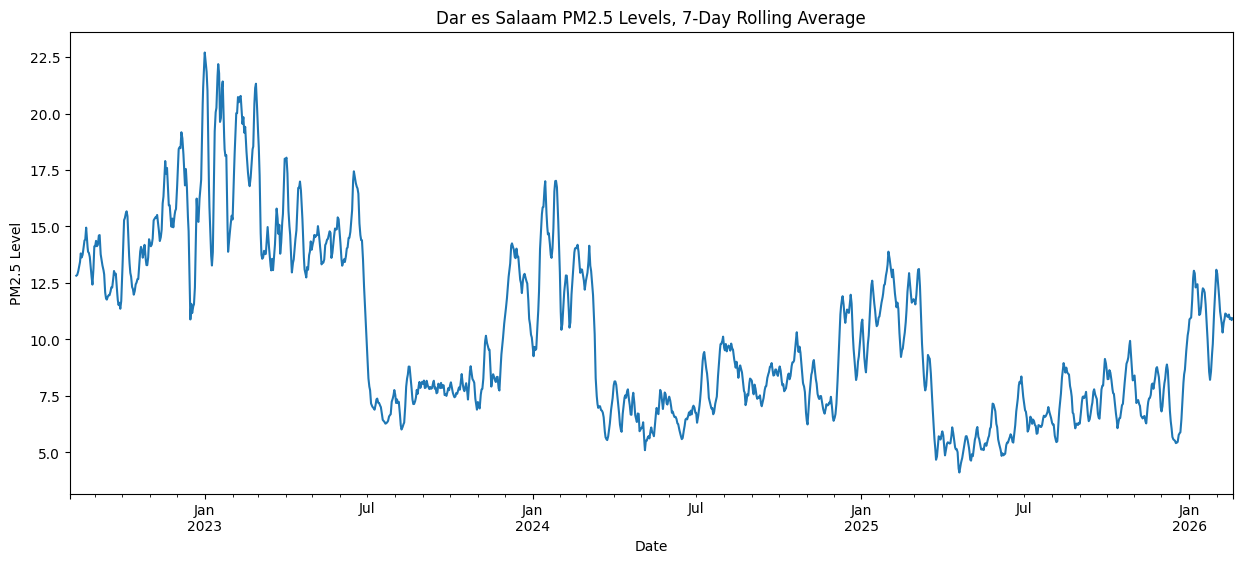

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))

# use ax=ax in your plot
df.rolling(168).mean().plot(ax=ax, ylabel="PM2.5 Level", xlabel="Date", title="Dar es Salaam PM2.5 Levels, 7-Day Rolling Average");

Plot a acf plot

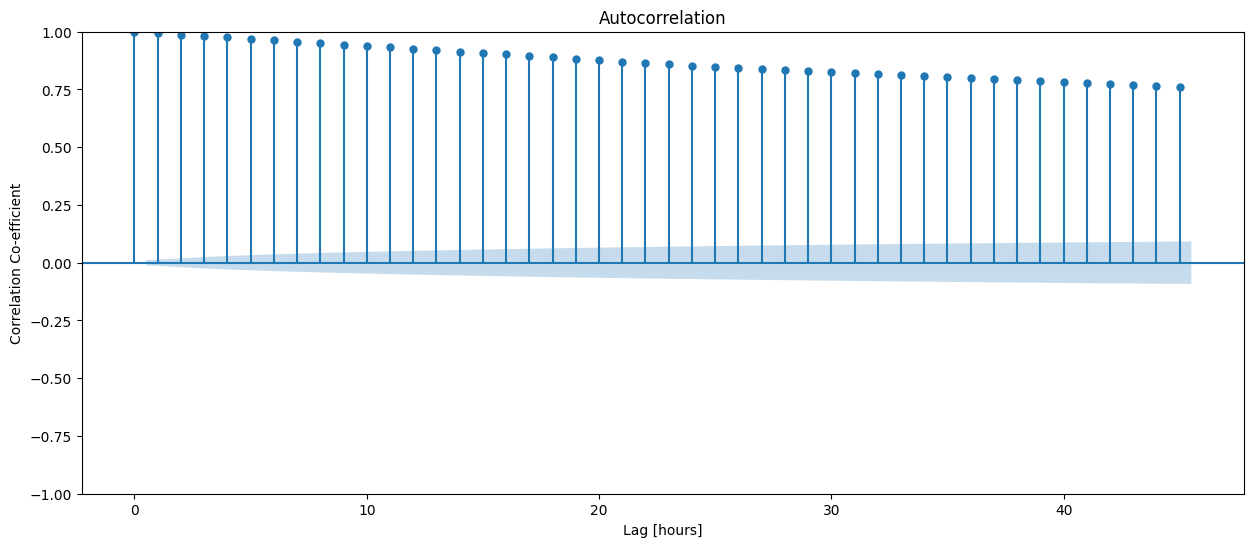

In [6]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_acf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Co-efficient");

Plot a PACF plot

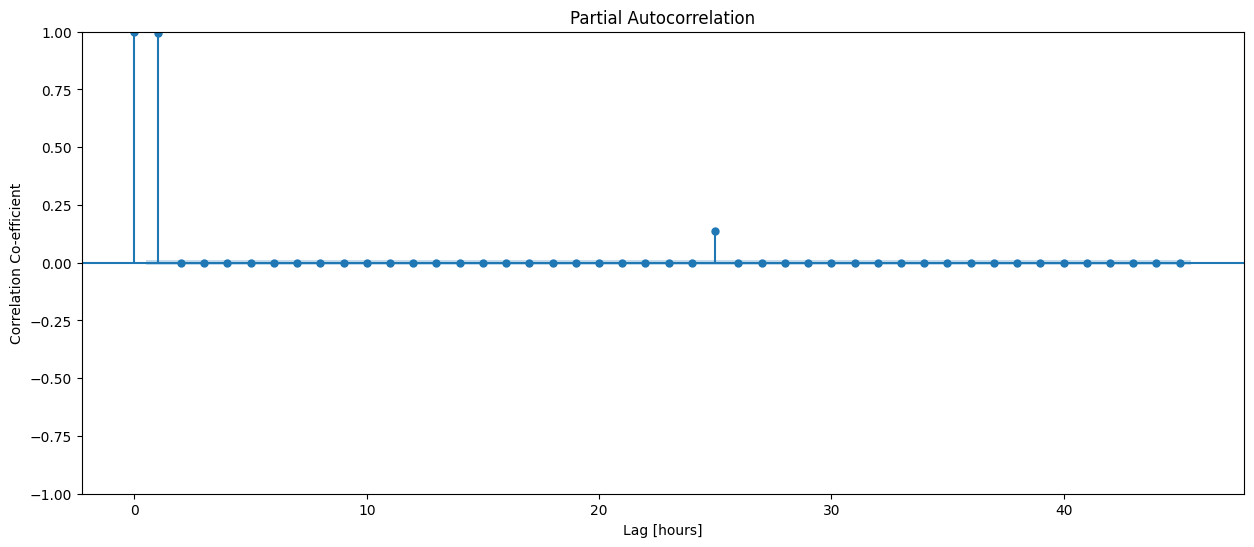

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_pacf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Co-efficient");

SPLIT

In [12]:
cutoff_test = int(len(df) * 0.90) 
df_train = df.iloc[:cutoff_test]
df_test = df.iloc[cutoff_test:]
print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

df_train shape: (27951,)
df_test shape: (3106,)


Iterate

In [13]:
# Create range to test different lags
p_params = range(1, 31)

# Create empty list to hold mean absolute error scores
maes = []

# Iterate through all values of p in `p_params`
for p in p_params:
    # Build model
    model = AutoReg(df_train, lags=p).fit()

    # Make predictions on training data, dropping null values caused by lag
    df_pred = model.predict().dropna()

    # Calculate mean absolute error for training data vs predictions
    mae = mean_absolute_error(df_train.iloc[p:], df_pred)

    # Append `mae` to list `maes`
    maes.append(mae)

# Put list `maes` into Series with index `p_params`
mae_series = pd.Series(maes, name="mae", index=p_params)

# Inspect head of Series
mae_series

1     0.091307
2     0.091358
3     0.091409
4     0.091461
5     0.091513
6     0.091565
7     0.091618
8     0.091670
9     0.091724
10    0.091777
11    0.091831
12    0.091885
13    0.091940
14    0.091995
15    0.092050
16    0.092105
17    0.092161
18    0.092217
19    0.092274
20    0.092331
21    0.092388
22    0.092446
23    0.092504
24    0.092562
25    0.088554
26    0.088592
27    0.088630
28    0.088668
29    0.088707
30    0.088746
Name: mae, dtype: float64

In [18]:
best_p = 25
best_model = AutoReg(df_train, lags=best_p).fit()

In [19]:
df_train_resid = best_model.resid
df_train_resid.name = "residuals"
df_train_resid.head()

timestamp
2022-08-05 04:00:00+03:00    0.011048
2022-08-05 05:00:00+03:00    0.011048
2022-08-05 06:00:00+03:00    0.011048
2022-08-05 07:00:00+03:00    0.011048
2022-08-05 08:00:00+03:00    0.011048
Freq: h, Name: residuals, dtype: float64

Plot Histogram of the Residuals

Text(0.5, 1.0, 'Best Model, Training Residuals')

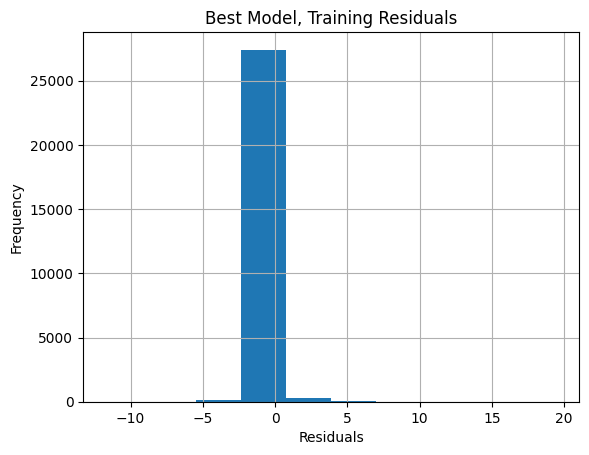

In [21]:
# Plot histogram of residuals
fig, ax = plt.subplots()

# Use ax=ax in your plot
df_train_resid.hist()
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Best Model, Training Residuals")

Plot the ACF for the residuals

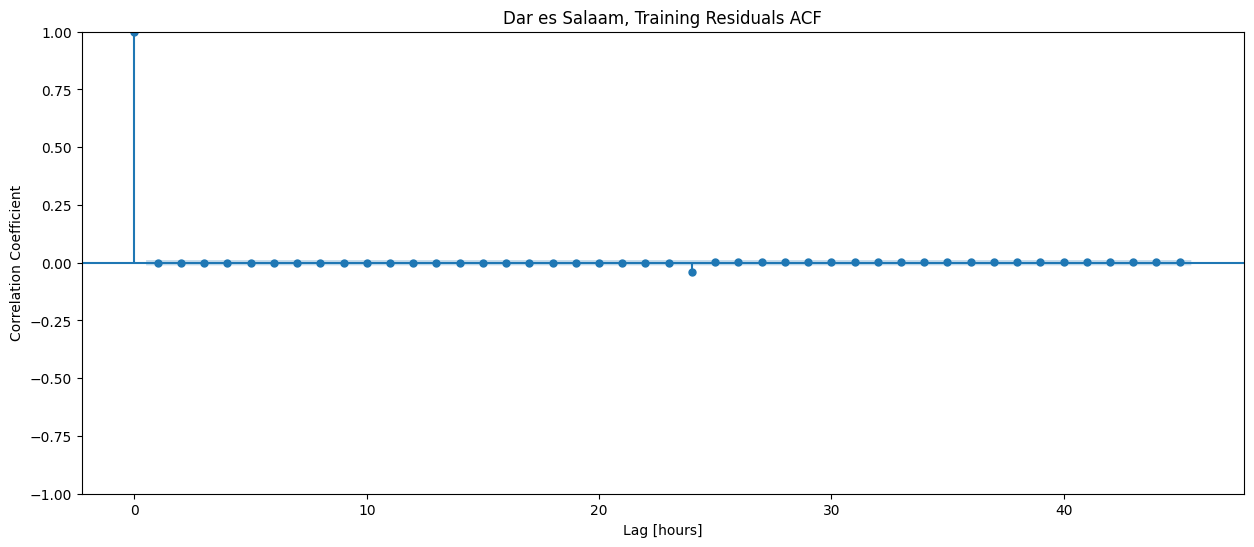

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))

# Use ax=ax in your plot
plot_acf(df_train_resid, ax=ax);
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Dar es Salaam, Training Residuals ACF");

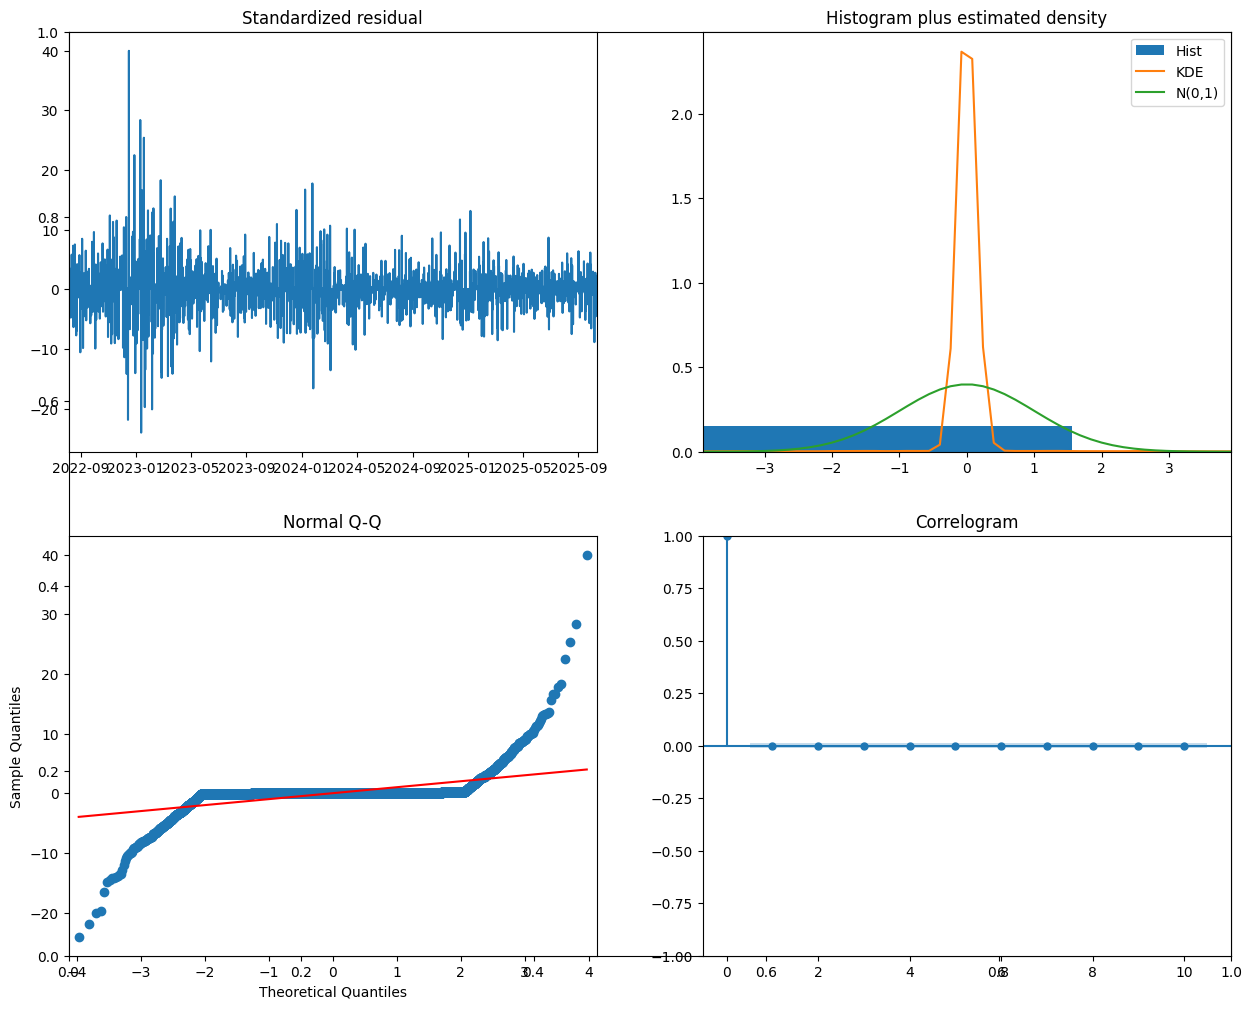

In [24]:
fig, ax = plt.subplots(figsize=(15, 12))

best_model.plot_diagnostics(fig=fig);

EVALUATE THE MODEL

In [26]:
df_pred_wfv = pd.Series()
history = df_train.copy()

for i in range(len(df_test)):
    model = AutoReg(history, lags=25).fit()
    next_pred = model.forecast()
    df_pred_wfv = pd.concat([df_pred_wfv, next_pred])
    history = pd.concat([history, df_test[next_pred.index]])



C:\Users\Johnt\AppData\Local\Temp\ipykernel_18144\3824851216.py:7: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pred_wfv = pd.concat([df_pred_wfv, next_pred])


In [28]:
test_mae = mean_absolute_error(df_test, df_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 0.07


COMMUNICATE RESULTS

In [29]:
print(model.params)

const        5.786641e-02
pm2_5.L1     9.971488e-01
pm2_5.L2     2.697547e-15
pm2_5.L3    -3.276285e-15
pm2_5.L4    -1.342796e-15
pm2_5.L5     1.574246e-15
pm2_5.L6    -2.424371e-15
pm2_5.L7     6.906170e-16
pm2_5.L8     2.323011e-15
pm2_5.L9    -1.355268e-15
pm2_5.L10   -7.368772e-16
pm2_5.L11    3.712125e-15
pm2_5.L12   -2.547758e-15
pm2_5.L13   -1.439880e-15
pm2_5.L14   -1.334313e-16
pm2_5.L15    6.606473e-16
pm2_5.L16    4.023287e-16
pm2_5.L17   -8.590730e-16
pm2_5.L18    5.600707e-16
pm2_5.L19   -4.892511e-16
pm2_5.L20   -1.431424e-15
pm2_5.L21    2.090559e-15
pm2_5.L22   -1.048014e-15
pm2_5.L23   -6.510073e-16
pm2_5.L24   -1.424464e-01
pm2_5.L25    1.395952e-01
dtype: float64


In [30]:
df_pred_test = pd.DataFrame(
    {"df_test": df_test, "df_pred_wfv": df_pred_wfv}
)

fig = px.line(df_pred_test, labels={"value": "PM2.5"})
fig.show()